In [3]:
# Generate a realistic dataset with 10,000 rows using pandas and faker, with some nulls in mail_id and ph_no
import pandas as pd
import numpy as np
from faker import Faker
import random

fake = Faker()

occupations = [
    'Software Engineer', 'Teacher', 'Doctor', 'Nurse', 'Accountant', 'Salesperson',
    'Manager', 'Driver', 'Clerk', 'Electrician', 'Mechanic', 'Chef', 'Artist',
    'Scientist', 'Lawyer', 'Police Officer', 'Pharmacist', 'Consultant', 'Analyst', 'Farmer'
]

def generate_row_with_nulls():
    age = random.randint(18, 70)
    # income between 75k and 2.5L
    income = random.randint(75000, 250000)
    # budget should be between 50k and 2L, and not exceed income
    max_budget = min(income, 200000)
    min_budget = 50000
    if max_budget < min_budget:
        budget = max_budget  # fallback: budget equals income if income < 50k
    else:
        budget = random.randint(min_budget, max_budget)
    ph_no = fake.phone_number() if np.random.rand() > 0.1 else None  # 10% null
    mail_id = fake.email() if np.random.rand() > 0.1 else None      # 10% null
    rented_house = random.choice(['Yes', 'No'])
    insurance = random.choice(['Yes', 'No'])
    occupation = random.choice(occupations)
    return [age, income, budget, ph_no, mail_id, rented_house, insurance, occupation]

num_rows = 10000
data = [generate_row_with_nulls() for _ in range(num_rows)]

columns = ['age', 'income', 'budget', 'ph_no', 'mail_id', 'rented_house', 'insurance', 'occupation']
df = pd.DataFrame(data, columns=columns)

In [7]:
df['rented_house'] = df['rented_house'].astype('string')
df['insurance'] = df['insurance'].astype('string')
df['occupation'] = df['occupation'].astype('string')
df['mail_id'] = df['mail_id'].astype('string')
df['ph_no'] = df['ph_no'].astype('string')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           10000 non-null  int64 
 1   income        10000 non-null  int64 
 2   budget        10000 non-null  int64 
 3   ph_no         9043 non-null   string
 4   mail_id       8952 non-null   string
 5   rented_house  10000 non-null  string
 6   insurance     10000 non-null  string
 7   occupation    10000 non-null  string
dtypes: int64(3), string(5)
memory usage: 625.1 KB


In [10]:
df.describe()

,age,income,budget
count,10000.00000,10000.000000,10000.000000
mean,43.95600,162771.095500,103493.958300
std,15.34453,50185.913788,38630.547305
min,18.00000,75024.000000,50008.000000
25%,31.00000,120245.250000,71129.500000
50%,44.00000,162955.500000,95669.000000
75%,57.00000,206413.250000,129414.750000
max,70.00000,249953.000000,199898.000000


In [11]:
df.describe(include='all')

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
count,10000.00000,10000.000000,10000.000000,9043,8952,10000,10000,10000
unique,NaN,NaN,NaN,9043,8785,2,2,20
top,NaN,NaN,NaN,(849)465-5675x23290,lbrown@example.net,No,Yes,Manager
freq,NaN,NaN,NaN,1,4,5008,5011,532
mean,43.95600,162771.095500,103493.958300,NaN,NaN,NaN,NaN,NaN
std,15.34453,50185.913788,38630.547305,NaN,NaN,NaN,NaN,NaN
min,18.00000,75024.000000,50008.000000,NaN,NaN,NaN,NaN,NaN
25%,31.00000,120245.250000,71129.500000,NaN,NaN,NaN,NaN,NaN
50%,44.00000,162955.500000,95669.000000,NaN,NaN,NaN,NaN,NaN
75%,57.00000,206413.250000,129414.750000,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isna().sum()

age                0
income             0
budget             0
ph_no            957
mail_id         1048
rented_house       0
insurance          0
occupation         0
dtype: int64

<Axes: xlabel='rented_house', ylabel='income'>

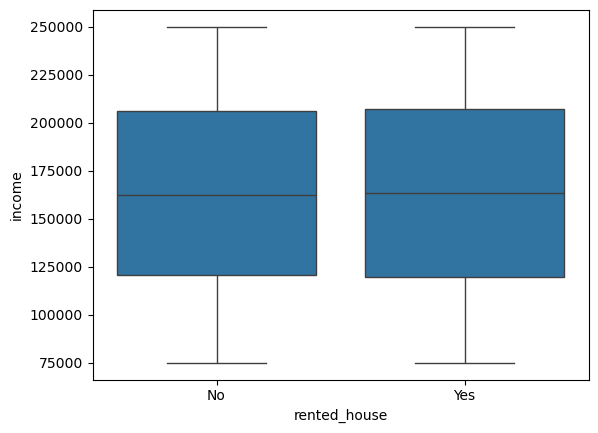

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='rented_house', y='income', data=df)

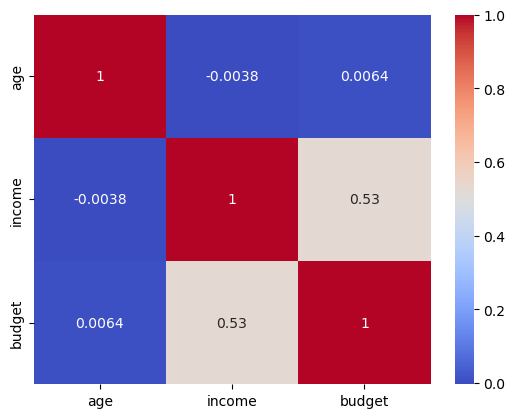

In [23]:
#df to correlation

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [24]:
df.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,35,229397,84350,(849)465-5675x23290,john64@example.org,No,No,Mechanic
1,18,135659,133543,826.727.5655,kimthompson@example.net,Yes,No,Teacher
2,55,241571,183595,364-345-6190x319,<NA>,No,No,Nurse
3,47,132617,92657,+1-861-351-9607x16694,<NA>,No,No,Scientist
4,32,131417,129528,(330)567-8143x8277,nandrews@example.net,No,No,Farmer


In [25]:
df.tail()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
9995,58,224933,97594,(596)796-1861x074,shawna76@example.org,Yes,Yes,Driver
9996,46,82818,68283,849.533.9086x78014,robertthompson@example.org,Yes,Yes,Accountant
9997,32,197083,132634,4456777435,barbara70@example.net,Yes,No,Artist
9998,53,194655,125894,719-913-7091x6634,georgewoods@example.org,No,Yes,Driver
9999,40,170312,161239,889-213-1906x8450,lindastevens@example.org,Yes,No,Nurse


In [26]:
df.shape

(10000, 8)

In [27]:
df_cleaned = df.dropna(subset=['ph_no'])


In [30]:
df_cleaned.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,35,229397,84350,(849)465-5675x23290,john64@example.org,No,No,Mechanic
1,18,135659,133543,826.727.5655,kimthompson@example.net,Yes,No,Teacher
2,55,241571,183595,364-345-6190x319,<NA>,No,No,Nurse
3,47,132617,92657,+1-861-351-9607x16694,<NA>,No,No,Scientist
4,32,131417,129528,(330)567-8143x8277,nandrews@example.net,No,No,Farmer


In [31]:
df_cleaned.shape

(9043, 8)

In [35]:
df_cleaned.isna().sum()

age             0
income          0
budget          0
ph_no           0
mail_id         0
rented_house    0
insurance       0
occupation      0
dtype: int64

In [36]:
df_cleaned['mail_id'] = df_cleaned['mail_id'].fillna('unknown')

/var/folders/01/lklhpss12y11p3wyssjwlf_40000gn/T/ipykernel_77382/3084191316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['mail_id'] = df_cleaned['mail_id'].fillna('unknown')


In [38]:
df_cleaned.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,35,229397,84350,(849)465-5675x23290,john64@example.org,No,No,Mechanic
1,18,135659,133543,826.727.5655,kimthompson@example.net,Yes,No,Teacher
2,55,241571,183595,364-345-6190x319,unknown,No,No,Nurse
3,47,132617,92657,+1-861-351-9607x16694,unknown,No,No,Scientist
4,32,131417,129528,(330)567-8143x8277,nandrews@example.net,No,No,Farmer


In [39]:
df_cleaned.isna().sum()

age             0
income          0
budget          0
ph_no           0
mail_id         0
rented_house    0
insurance       0
occupation      0
dtype: int64

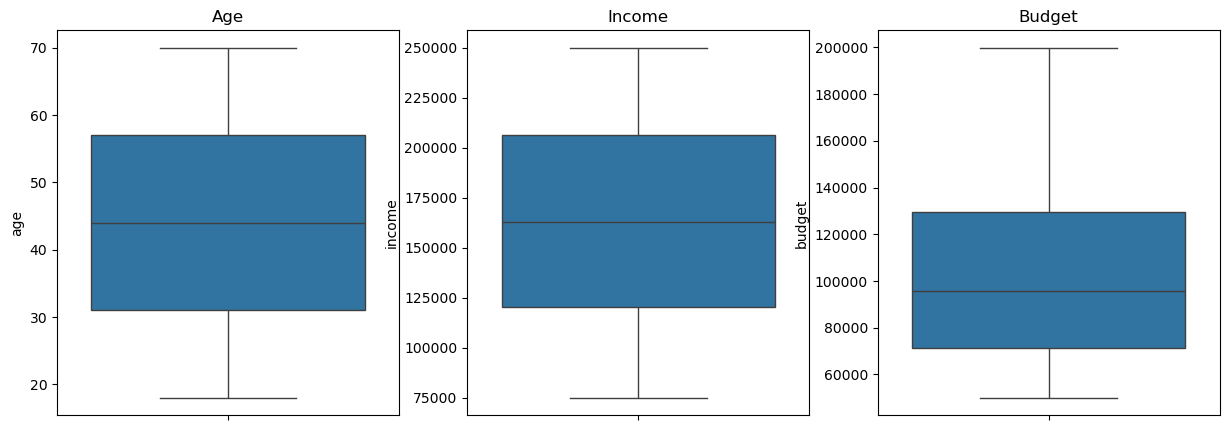

In [40]:
# box plot for age, income and budget columns to understand the distribution of these columns and to identify any outliers in these columns.

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_cleaned['age'])
plt.title('Age')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_cleaned['income'])
plt.title('Income')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_cleaned['budget'])
plt.title('Budget')

plt.show()

In [41]:
df_cleaned.describe(include='all')

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
count,9043.000000,9043.000000,9043.000000,9043,9043,9043,9043,9043
unique,NaN,NaN,NaN,9043,7972,2,2,20
top,NaN,NaN,NaN,(849)465-5675x23290,unknown,No,Yes,Salesperson
freq,NaN,NaN,NaN,1,938,4553,4531,485
mean,43.925357,162765.259759,103541.988278,NaN,NaN,NaN,NaN,NaN
std,15.379317,50072.106620,38603.953150,NaN,NaN,NaN,NaN,NaN
min,18.000000,75024.000000,50008.000000,NaN,NaN,NaN,NaN,NaN
25%,31.000000,120557.000000,71262.500000,NaN,NaN,NaN,NaN,NaN
50%,44.000000,163020.000000,95574.000000,NaN,NaN,NaN,NaN,NaN
75%,57.000000,206244.500000,129471.000000,NaN,NaN,NaN,NaN,NaN


In [42]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9043 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           9043 non-null   int64 
 1   income        9043 non-null   int64 
 2   budget        9043 non-null   int64 
 3   ph_no         9043 non-null   string
 4   mail_id       9043 non-null   string
 5   rented_house  9043 non-null   string
 6   insurance     9043 non-null   string
 7   occupation    9043 non-null   string
dtypes: int64(3), string(5)
memory usage: 635.8 KB


In [43]:
df_for_clustering = df_cleaned[['age', 'income', 'budget', 'rented_house', 'insurance', 'occupation']]

In [44]:
df_for_clustering.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9043 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           9043 non-null   int64 
 1   income        9043 non-null   int64 
 2   budget        9043 non-null   int64 
 3   rented_house  9043 non-null   string
 4   insurance     9043 non-null   string
 5   occupation    9043 non-null   string
dtypes: int64(3), string(3)
memory usage: 494.5 KB


In [45]:
# i would like to apply the k-means clustering algorithm to group the customers based on their age, income and budget for buying a house.

# in this code flow we are training on numeric columns only -- age, income and budget columns -- we are not using rented_house, insurance and occupation columns for clustering analysis as they are categorical columns and k-means algorithm works well with numeric data.
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Select the features for clustering
#X = df_for_clustering[['age', 'income', 'budget']]

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # n_clusters is the number of clusters we want to create and random_state is used to ensure reproducibility of the results

kmeans.fit(df_for_clustering[['age', 'income', 'budget']])  # fit is used to train the model on the data

# Add the cluster labels to the dataframe
df_for_clustering['cluster'] = kmeans.labels_  # labels_ is used to get the cluster labels assigned to each data point by the K-means algorithm

/var/folders/01/lklhpss12y11p3wyssjwlf_40000gn/T/ipykernel_77382/1279997793.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_clustering['cluster'] = kmeans.labels_  # labels_ is used to get the cluster labels assigned to each data point by the K-means algorithm


In [46]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster
0,35,229397,84350,No,No,Mechanic,2
1,18,135659,133543,Yes,No,Teacher,1
2,55,241571,183595,No,No,Nurse,0
3,47,132617,92657,No,No,Scientist,1
4,32,131417,129528,No,No,Farmer,1


In [47]:
df_for_clustering['cluster'].value_counts()


cluster
1    4031
2    2547
0    2465
Name: count, dtype: int64

In [48]:
df_cleaned_with_clusters = df_cleaned.copy()

In [49]:
df_cleaned_with_clusters

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,35,229397,84350,(849)465-5675x23290,john64@example.org,No,No,Mechanic
1,18,135659,133543,826.727.5655,kimthompson@example.net,Yes,No,Teacher
2,55,241571,183595,364-345-6190x319,unknown,No,No,Nurse
3,47,132617,92657,+1-861-351-9607x16694,unknown,No,No,Scientist
4,32,131417,129528,(330)567-8143x8277,nandrews@example.net,No,No,Farmer
...,...,...,...,...,...,...,...,...
9995,58,224933,97594,(596)796-1861x074,shawna76@example.org,Yes,Yes,Driver
9996,46,82818,68283,849.533.9086x78014,robertthompson@example.org,Yes,Yes,Accountant
9997,32,197083,132634,4456777435,barbara70@example.net,Yes,No,Artist
9998,53,194655,125894,719-913-7091x6634,georgewoods@example.org,No,Yes,Driver


In [51]:
df_cleaned_with_clusters['cluster_with_num_cols_only'] = kmeans.labels_

In [52]:
df_cleaned_with_clusters['cluster_with_num_cols_only'].value_counts()

cluster_with_num_cols_only
1    4031
2    2547
0    2465
Name: count, dtype: int64

In [53]:
df_cleaned_with_clusters.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only
0,35,229397,84350,(849)465-5675x23290,john64@example.org,No,No,Mechanic,2
1,18,135659,133543,826.727.5655,kimthompson@example.net,Yes,No,Teacher,1
2,55,241571,183595,364-345-6190x319,unknown,No,No,Nurse,0
3,47,132617,92657,+1-861-351-9607x16694,unknown,No,No,Scientist,1
4,32,131417,129528,(330)567-8143x8277,nandrews@example.net,No,No,Farmer,1


In [54]:
df_for_clustering

,age,income,budget,rented_house,insurance,occupation,cluster
0,35,229397,84350,No,No,Mechanic,2
1,18,135659,133543,Yes,No,Teacher,1
2,55,241571,183595,No,No,Nurse,0
3,47,132617,92657,No,No,Scientist,1
4,32,131417,129528,No,No,Farmer,1
...,...,...,...,...,...,...,...
9995,58,224933,97594,Yes,Yes,Driver,2
9996,46,82818,68283,Yes,Yes,Accountant,1
9997,32,197083,132634,Yes,No,Artist,0
9998,53,194655,125894,No,Yes,Driver,0


In [55]:
df_cleaned_with_clusters.head(2)

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only
0,35,229397,84350,(849)465-5675x23290,john64@example.org,No,No,Mechanic,2
1,18,135659,133543,826.727.5655,kimthompson@example.net,Yes,No,Teacher,1


In [56]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster
0,35,229397,84350,No,No,Mechanic,2
1,18,135659,133543,Yes,No,Teacher,1
2,55,241571,183595,No,No,Nurse,0
3,47,132617,92657,No,No,Scientist,1
4,32,131417,129528,No,No,Farmer,1


In [57]:
df_for_clustering['rented_house'].value_counts()

rented_house
No     4553
Yes    4490
Name: count, dtype: Int64

In [58]:
df_for_clustering['insurance'].value_counts()

insurance
Yes    4531
No     4512
Name: count, dtype: Int64

In [59]:
df_for_clustering['occupation'].nunique()

20

In [60]:
df_for_clustering['occupation'].value_counts()

occupation
Salesperson          485
Manager              483
Electrician          481
Scientist            471
Doctor               471
Consultant           468
Nurse                464
Lawyer               457
Driver               444
Police Officer       443
Analyst              442
Pharmacist           442
Artist               442
Chef                 441
Mechanic             437
Teacher              436
Clerk                435
Software Engineer    435
Accountant           434
Farmer               432
Name: count, dtype: Int64

In [63]:
# let's apply Label Encoding to the 'rented_house', 'insurance' and 'occupation' columns in the df_for_clustering dataframe.
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_for_clustering['rented_house_label'] = label_encoder.fit_transform(df_for_clustering['rented_house'])

In [64]:
df_for_clustering['occupation_label'] = label_encoder.fit_transform(df_for_clustering['occupation'])

In [66]:
df_for_clustering['insurance_label'] = label_encoder.fit_transform(df_for_clustering['insurance'])

In [67]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,occupation_label,insurance_label
0,35,229397,84350,No,No,Mechanic,2,0,12,0
1,18,135659,133543,Yes,No,Teacher,1,1,19,0
2,55,241571,183595,No,No,Nurse,0,0,13,0
3,47,132617,92657,No,No,Scientist,1,0,17,0
4,32,131417,129528,No,No,Farmer,1,0,9,0


In [68]:
df_for_clustering['occupation_label'] = label_encoder.fit_transform(df_for_clustering['occupation'])

In [69]:
df_for_clustering.columns

Index(['age', 'income', 'budget', 'rented_house', 'insurance', 'occupation',
       'cluster', 'rented_house_label', 'occupation_label', 'insurance_label'],
      dtype='object')

In [70]:
df_with_label_encoded = df_for_clustering[['age', 'income', 'budget',
       'rented_house_label', 'insurance_label', 'occupation_label']]

In [71]:
df_with_label_encoded.head(2)

,age,income,budget,rented_house_label,insurance_label,occupation_label
0,35,229397,84350,0,0,12
1,18,135659,133543,1,0,19


In [72]:
df_with_label_encoded.isna().sum()

age                   0
income                0
budget                0
rented_house_label    0
insurance_label       0
occupation_label      0
dtype: int64

In [73]:
# i would like to apply the k-means clustering algorithm to group the customers based on their age, income and budget for buying a house.

# in this code flow we are training on numeric columns only -- age, income and budget columns -- we are not using rented_house, insurance and occupation columns for clustering analysis as they are categorical columns and k-means algorithm works well with numeric data.
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Select the features for clustering
#X = df_for_clustering[['age', 'income', 'budget']]

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # n_clusters is the number of clusters we want to create and random_state is used to ensure reproducibility of the results

kmeans.fit(df_with_label_encoded)  # fit is used to train the model on the data

# Add the cluster labels to the dataframe
df_cleaned_with_clusters['cluster_with_cat_cols_also'] = kmeans.labels_  # labels_ is used to get the cluster labels assigned to each data point by the K-means algorithm

In [74]:
df_cleaned_with_clusters.head(2)

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only,cluster_with_cat_cols_also
0,35,229397,84350,(849)465-5675x23290,john64@example.org,No,No,Mechanic,2,2
1,18,135659,133543,826.727.5655,kimthompson@example.net,Yes,No,Teacher,1,1


In [75]:
df_cleaned_with_clusters['cluster_with_num_cols_only'].value_counts()

cluster_with_num_cols_only
1    4031
2    2547
0    2465
Name: count, dtype: int64

In [76]:
# Find optimal number of clusters using Elbow Method and Silhouette Score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df_with_label_encoded  # Use your feature DataFrame

wcss = [] # -- within cluster sum of scores
silhouette_scores = []
K = range(2, 11)  # - taking clusters from 2 onwards till 10 clusters
print(" printing K values after range function ")
print(K)

for k in K:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    print("wcss score is")
    print(wcss)
    silhouette_scores.append(silhouette_score(X, labels))
    print("silhouette_score is")
    print(silhouette_scores)

 printing K values after range function 
range(2, 11)
2
wcss score is
[15317044106046.633]
silhouette_score is
[0.4813320105761768]
3
wcss score is
[15317044106046.633, 10072131511115.947]
silhouette_score is
[0.4813320105761768, 0.4454917844897564]
4
wcss score is
[15317044106046.633, 10072131511115.947, 7070992437993.941]
silhouette_score is
[0.4813320105761768, 0.4454917844897564, 0.4286749948128205]
5
wcss score is
[15317044106046.633, 10072131511115.947, 7070992437993.941, 5616300616162.459]
silhouette_score is
[0.4813320105761768, 0.4454917844897564, 0.4286749948128205, 0.41604022646005534]
6
wcss score is
[15317044106046.633, 10072131511115.947, 7070992437993.941, 5616300616162.459, 4604312384215.599]
silhouette_score is
[0.4813320105761768, 0.4454917844897564, 0.4286749948128205, 0.41604022646005534, 0.4080878072077188]
7
wcss score is
[15317044106046.633, 10072131511115.947, 7070992437993.941, 5616300616162.459, 4604312384215.599, 4060922856410.56]
silhouette_score is
[0.48133

Text(0.5, 1.0, 'Elbow Method')

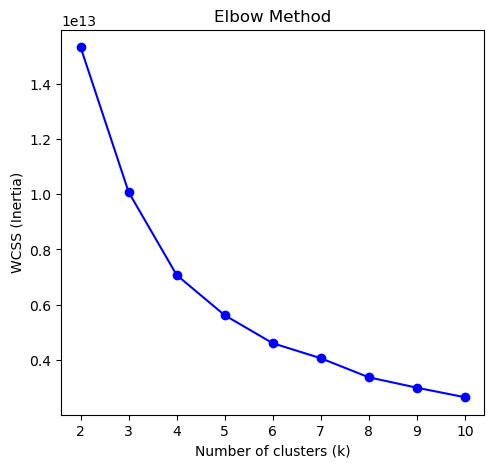

In [77]:
# Plot Elbow Method  -- is nothign but plotting between number of clusters on X-Axis and wcss score on Y-axis 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method')

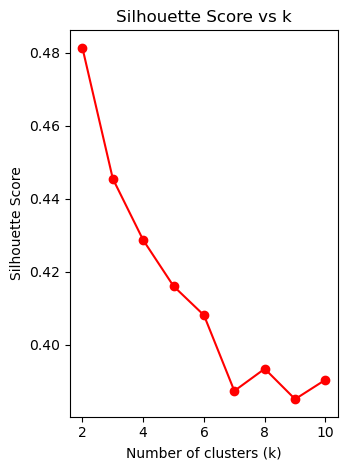

In [78]:
# Plot Silhouette Score
plt.subplot(1,2,2)
plt.plot(K, silhouette_scores, 'ro-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')

plt.tight_layout()
plt.show()

In [79]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,occupation_label,insurance_label
0,35,229397,84350,No,No,Mechanic,2,0,12,0
1,18,135659,133543,Yes,No,Teacher,1,1,19,0
2,55,241571,183595,No,No,Nurse,0,0,13,0
3,47,132617,92657,No,No,Scientist,1,0,17,0
4,32,131417,129528,No,No,Farmer,1,0,9,0


In [80]:
df_for_clustering_with_onehot = pd.get_dummies(df_for_clustering, dtype=float)

In [81]:
df_for_clustering_with_onehot.isna().sum()

age                             0
income                          0
budget                          0
cluster                         0
rented_house_label              0
occupation_label                0
insurance_label                 0
rented_house_No                 0
rented_house_Yes                0
insurance_No                    0
insurance_Yes                   0
occupation_Accountant           0
occupation_Analyst              0
occupation_Artist               0
occupation_Chef                 0
occupation_Clerk                0
occupation_Consultant           0
occupation_Doctor               0
occupation_Driver               0
occupation_Electrician          0
occupation_Farmer               0
occupation_Lawyer               0
occupation_Manager              0
occupation_Mechanic             0
occupation_Nurse                0
occupation_Pharmacist           0
occupation_Police Officer       0
occupation_Salesperson          0
occupation_Scientist            0
occupation_Sof

In [82]:
df_for_clustering_with_onehot.head(2)


,age,income,budget,cluster,rented_house_label,occupation_label,insurance_label,rented_house_No,rented_house_Yes,insurance_No,...,occupation_Lawyer,occupation_Manager,occupation_Mechanic,occupation_Nurse,occupation_Pharmacist,occupation_Police Officer,occupation_Salesperson,occupation_Scientist,occupation_Software Engineer,occupation_Teacher
0,35,229397,84350,2,0,12,0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18,135659,133543,1,1,19,0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [83]:
df_for_clustering_with_onehot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9043 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           9043 non-null   int64  
 1   income                        9043 non-null   int64  
 2   budget                        9043 non-null   int64  
 3   cluster                       9043 non-null   int32  
 4   rented_house_label            9043 non-null   int64  
 5   occupation_label              9043 non-null   int64  
 6   insurance_label               9043 non-null   int64  
 7   rented_house_No               9043 non-null   float64
 8   rented_house_Yes              9043 non-null   float64
 9   insurance_No                  9043 non-null   float64
 10  insurance_Yes                 9043 non-null   float64
 11  occupation_Accountant         9043 non-null   float64
 12  occupation_Analyst            9043 non-null   float64
 13  occupati

In [84]:
# i would like to apply the k-means clustering algorithm to group the customers based on their age, income and budget for buying a house.

# in this code flow we are training on numeric columns only -- age, income and budget columns -- we are not using rented_house, insurance and occupation columns for clustering analysis as they are categorical columns and k-means algorithm works well with numeric data.
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Select the features for clustering
#X = df_for_clustering[['age', 'income', 'budget']]

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # n_clusters is the number of clusters we want to create and random_state is used to ensure reproducibility of the results

kmeans.fit(df_for_clustering_with_onehot)  # fit is used to train the model on the data

# Add the cluster labels to the dataframe
df_cleaned_with_clusters['cluster_with_onehot'] = kmeans.labels_  # labels_ is used to get the cluster labels assigned to each data point by the K-means algorithm

In [85]:
df_cleaned_with_clusters.head(2)

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only,cluster_with_cat_cols_also,cluster_with_onehot
0,35,229397,84350,(849)465-5675x23290,john64@example.org,No,No,Mechanic,2,2,2
1,18,135659,133543,826.727.5655,kimthompson@example.net,Yes,No,Teacher,1,1,1


In [87]:
df_cleaned_with_clusters['cluster_with_onehot'].value_counts()

cluster_with_onehot
1    4036
2    2543
0    2464
Name: count, dtype: int64

In [91]:
df_for_clustering_with_onehot.head(2)

,age,income,budget,cluster,rented_house_label,occupation_label,insurance_label,rented_house_No,rented_house_Yes,insurance_No,...,occupation_Lawyer,occupation_Manager,occupation_Mechanic,occupation_Nurse,occupation_Pharmacist,occupation_Police Officer,occupation_Salesperson,occupation_Scientist,occupation_Software Engineer,occupation_Teacher
0,35,229397,84350,2,0,12,0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18,135659,133543,1,1,19,0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [93]:
df_for_clustering_with_onehot['cluster'].value_counts()

cluster
1    4031
2    2547
0    2465
Name: count, dtype: int64